# Feature selection

In [ ]:
!pip install matplotlib


In [ ]:
import matplotlib.pyplot as plt
from src.model import *
from api.run import load_model

version = 'v1'
model, preprocessor, metadata = load_model(version)

df = load_dataset()
df = clean_dataset(df, version)
target_column = get_target_column(df)
y = df[target_column]
X = df.drop(target_column, axis=1)
X_train, y_train, X_test, y_test = train_test_split(X, y, train_size=HOLD_OUT)

X_features = preprocessor.get_feature_names_out()


## Gradient Boosting Regressor Coefficients


                                                 score
features                                              
num_transformer__sales_price                  0.607288
cat_transformer__series_gtk                   0.087156
cat_transformer__product_gtk 500              0.059246
num_transformer__duration                     0.053944
num_transformer__revenue                      0.039693
cat_transformer__series_mg                    0.023687
cat_transformer__product_mg advanced          0.017358
cat_transformer__account_xx-holding           0.015235
cat_transformer__account_singletechno         0.012063
cat_transformer__regional_office_west         0.006865
cat_transformer__sector_medical               0.006729
cat_transformer__product_gtxpro               0.005495
cat_transformer__sector_finance               0.005211
cat_transformer__product_gtx plus pro         0.005043
cat_transformer__account_donware              0.004623
cat_transformer__manager_celia rouche         0.004305
cat_transf

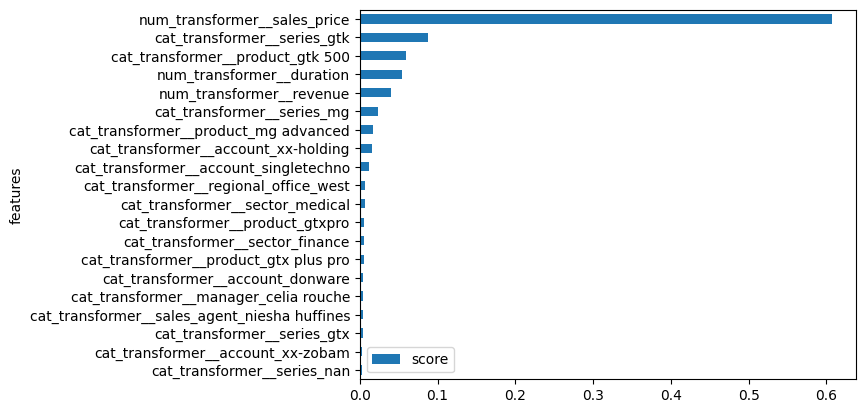

In [ ]:
fi = pd.DataFrame({
    'features': X_features,
    'score': model.feature_importances_
})
top_10 = fi.sort_values(by='score', ascending=False).head(20)
top_10.set_index('features', inplace=True)
top_10.sort_values(by='score', ascending=True).plot(kind='barh', y='score')
print(top_10)


In [ ]:
# Optional: Evaluate the model
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)
print(f"\nR-squared (Training Set): {train_score:.4f}")
print(f"R-squared (Test Set): {test_score:.4f}")


/home/ubuntu/.pyenv/versions/aisrm-env/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but GradientBoostingRegressor was fitted without feature names
  warnings.warn(


ValueError: could not convert string to float: 'donn cantrell'

## Lasso Regression Coefficients

In [ ]:
X_train_scaled = preprocessor.transform(X_train)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_features)
X_train_scaled_df


,num_transformer__revenue,num_transformer__sales_price,num_transformer__duration,num_transformer__won,cat_transformer__sales_agent_anna snelling,cat_transformer__sales_agent_boris faz,cat_transformer__sales_agent_cassey cress,cat_transformer__sales_agent_cecily lampkin,cat_transformer__sales_agent_corliss cosme,cat_transformer__sales_agent_daniell hammack,...,cat_transformer__product_gtx basic,cat_transformer__product_gtx plus basic,cat_transformer__product_gtx plus pro,cat_transformer__product_gtxpro,cat_transformer__product_mg advanced,cat_transformer__product_mg special,cat_transformer__series_gtk,cat_transformer__series_gtx,cat_transformer__series_mg,cat_transformer__series_nan
0,0.561975,0.807949,-0.486842,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,0.625800,1.542737,0.105263,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,-0.717622,0.276860,-0.421053,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,-0.384097,0.276860,0.315789,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-0.000698,0.807949,0.815789,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2008,-0.547858,-0.192051,-0.421053,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2009,2.470958,-0.192051,0.368421,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2010,0.524390,0.807949,0.855263,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2011,0.530342,0.000000,0.500000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


## Random Forest (Fine-Tuned) Feature Importance

## Feature Permutation (Permutation Importance